In [2]:
import pandas as pd
import glob

path = "/Users/kubilib/Desktop/Master Thesis/Graphnet-Applications/Metadata/EventWeights/String340MC"

files = glob.glob(f"{path}/*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df

,RunID,SubrunID,EventID,SubEventID,energy,zenith,azimuth,finalStateX,finalStateY,columnDepth,oneweight
0,61,4294967295,1,0,7818.603150,0.974183,0.953043,0.113196,0.312104,5.780632e+05,8.794045e+09
1,61,4294967295,2,0,2324.379259,1.704915,0.561291,0.223003,0.118814,8.515072e+05,7.469065e+08
2,61,4294967295,3,0,140.958831,1.905356,2.482583,0.017878,0.363834,2.931290e+05,2.595542e+05
3,61,4294967295,4,0,1532.588042,1.166790,4.369836,0.156982,0.314757,6.163078e+05,1.977505e+08
4,61,4294967295,5,0,255.743951,1.779982,2.145346,0.149105,0.810825,3.457985e+05,1.353041e+06
...,...,...,...,...,...,...,...,...,...,...,...
24856,78,4294967295,196,0,1121.076734,3.090151,3.823487,0.359976,0.403734,7.063990e+05,1.058813e+08
24857,78,4294967295,197,0,622.011650,1.480147,2.181882,0.206721,0.536377,4.831660e+05,1.706638e+07
24858,78,4294967295,198,0,6806.465128,1.380649,6.130414,0.141319,0.124088,1.400422e+06,1.548341e+10
24859,78,4294967295,199,0,386.308950,0.462309,0.203192,0.058656,0.937690,4.776273e+05,5.201404e+06


In [2]:
for col in ["RunID", "SubrunID", "EventID", "SubEventID"]:
    print(f"{col}: {df[col].nunique()}")

RunID: 127
SubrunID: 1
EventID: 200
SubEventID: 1


In [3]:
len(glob.glob(f"{path}/*.csv"))

127

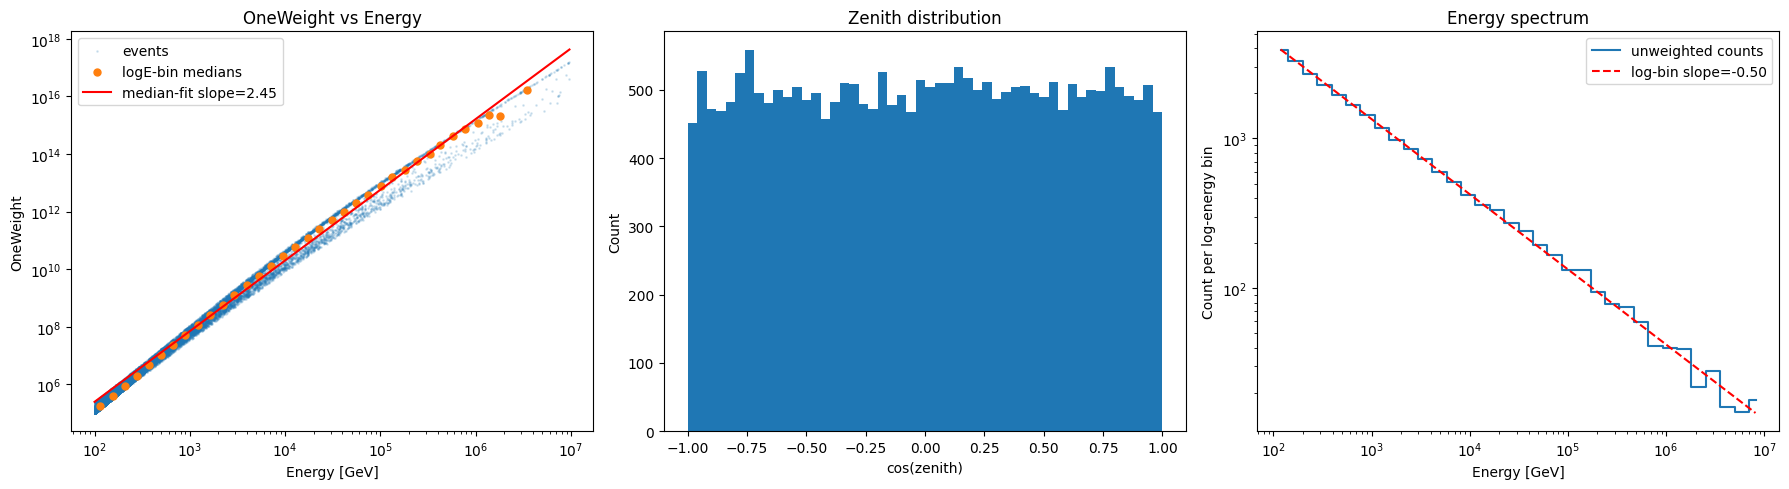

OneWeight vs Energy binned-median slope: 2.454
Energy histogram log-bin slope: -0.502

Note:
If generated dN/dE ~ E^-1.5, then histogram with log-spaced bins
usually looks like counts per logE bin ~ E^-0.5.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# df içinde şu kolonlar olmalı:
# df["energy"], df["oneweight"], df["zenith"]

# ------------------------------------------------------------
# Clean data
# ------------------------------------------------------------
valid = (
    np.isfinite(df["energy"]) &
    np.isfinite(df["oneweight"]) &
    np.isfinite(df["zenith"]) &
    (df["energy"] > 0) &
    (df["oneweight"] > 0)
)

df_clean = df.loc[valid].copy()

E = df_clean["energy"].values
W = df_clean["oneweight"].values
zenith = df_clean["zenith"].values

logE = np.log10(E)
logW = np.log10(W)


# ------------------------------------------------------------
# 1) OneWeight vs Energy
# Fit directly to binned medians, not all scatter points
# ------------------------------------------------------------
bins_logE = np.linspace(logE.min(), logE.max(), 40)
bin_id = np.digitize(logE, bins_logE)

x_med = []
y_med = []

for i in range(1, len(bins_logE)):
    mask = bin_id == i

    # Çok az event varsa fit'e alma
    if mask.sum() > 20:
        x_med.append(np.median(logE[mask]))
        y_med.append(np.median(logW[mask]))

x_med = np.array(x_med)
y_med = np.array(y_med)

slope_med, intercept_med = np.polyfit(x_med, y_med, 1)

e_range = np.logspace(logE.min(), logE.max(), 200)
fit_med = 10**intercept_med * e_range**slope_med


# ------------------------------------------------------------
# 2) Energy spectrum slope check
# Unweighted distribution
# ------------------------------------------------------------
energy_bins = np.logspace(logE.min(), logE.max(), 35)
counts, edges = np.histogram(E, bins=energy_bins)
centers = np.sqrt(edges[:-1] * edges[1:])

nonzero = counts > 0

# Bu log-bin count slope'udur.
# Eğer dN/dE ~ E^-1.5 ise log-bin histogram ~ E^-0.5 görünür.
energy_slope_logbin, energy_intercept = np.polyfit(
    np.log10(centers[nonzero]),
    np.log10(counts[nonzero]),
    1
)

energy_fit = 10**energy_intercept * centers**energy_slope_logbin


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: OneWeight vs Energy
axes[0].scatter(E, W, alpha=0.15, s=1, label="events")
axes[0].scatter(10**x_med, 10**y_med, s=25, label="logE-bin medians")
axes[0].plot(
    e_range,
    fit_med,
    "r-",
    label=f"median-fit slope={slope_med:.2f}"
)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Energy [GeV]")
axes[0].set_ylabel("OneWeight")
axes[0].set_title("OneWeight vs Energy")
axes[0].legend()


# Plot 2: Zenith distribution
axes[1].hist(np.cos(zenith), bins=50)
axes[1].set_xlabel("cos(zenith)")
axes[1].set_ylabel("Count")
axes[1].set_title("Zenith distribution")


# Plot 3: Energy spectrum
axes[2].step(centers, counts, where="mid", label="unweighted counts")
axes[2].plot(
    centers,
    energy_fit,
    "r--",
    label=f"log-bin slope={energy_slope_logbin:.2f}"
)

axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("Energy [GeV]")
axes[2].set_ylabel("Count per log-energy bin")
axes[2].set_title("Energy spectrum")
axes[2].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print(f"OneWeight vs Energy binned-median slope: {slope_med:.3f}")
print(f"Energy histogram log-bin slope: {energy_slope_logbin:.3f}")
print()
print("Note:")
print("If generated dN/dE ~ E^-1.5, then histogram with log-spaced bins")
print("usually looks like counts per logE bin ~ E^-0.5.")

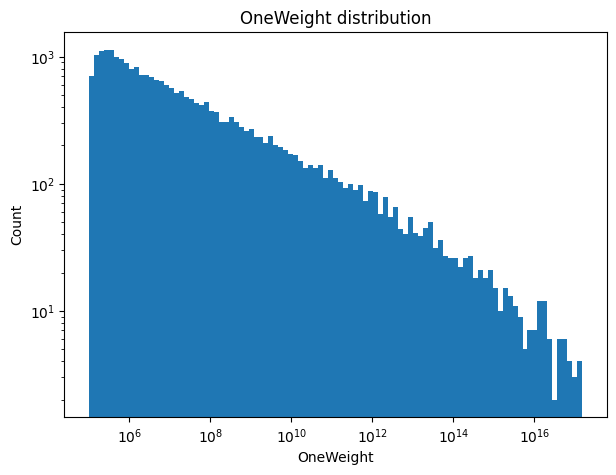

min = 102245.56578747374
max = 1.5289021837088586e+17
median = 5577595.867450905


In [6]:
import numpy as np
import matplotlib.pyplot as plt

w = df["oneweight"].values

valid = (
    np.isfinite(w) &
    (w > 0)
)

w = w[valid]

plt.figure(figsize=(7,5))

bins = np.logspace(
    np.log10(w.min()),
    np.log10(w.max()),
    100
)

plt.hist(w, bins=bins)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("OneWeight")
plt.ylabel("Count")
plt.title("OneWeight distribution")

plt.show()

print("min =", w.min())
print("max =", w.max())
print("median =", np.median(w))

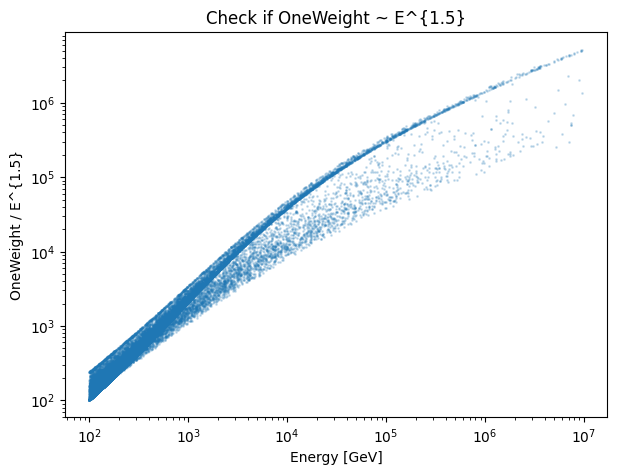

In [7]:
import numpy as np
import matplotlib.pyplot as plt

E = df["energy"].values
W = df["oneweight"].values

valid = (
    np.isfinite(E) &
    np.isfinite(W) &
    (E > 0) &
    (W > 0)
)

E = E[valid]
W = W[valid]

plt.figure(figsize=(7,5))

plt.scatter(
    E,
    W / (E**1.5),
    s=1,
    alpha=0.2
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy [GeV]")
plt.ylabel(r"OneWeight / E^{1.5}")

plt.title("Check if OneWeight ~ E^{1.5}")

plt.show()

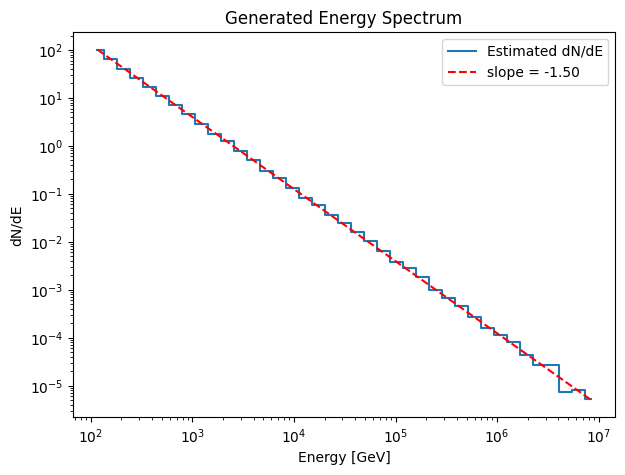

Measured dN/dE slope = -1.503


In [8]:
import numpy as np
import matplotlib.pyplot as plt

E = df["energy"].values

valid = (
    np.isfinite(E) &
    (E > 0)
)

E = E[valid]

# --------------------------------------------------
# LOG-SPACED BINS
# --------------------------------------------------
bins = np.logspace(
    np.log10(E.min()),
    np.log10(E.max()),
    40
)

counts, edges = np.histogram(E, bins=bins)

# bin centers
centers = np.sqrt(edges[:-1] * edges[1:])

# gerçek dN/dE estimate
bin_widths = np.diff(edges)

dnde = counts / bin_widths

# zero temizle
mask = dnde > 0

# slope fit
slope, intercept = np.polyfit(
    np.log10(centers[mask]),
    np.log10(dnde[mask]),
    1
)

fit = 10**intercept * centers**slope

# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(
    centers,
    dnde,
    drawstyle="steps-mid",
    label="Estimated dN/dE"
)

plt.plot(
    centers,
    fit,
    "r--",
    label=f"slope = {slope:.2f}"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy [GeV]")
plt.ylabel("dN/dE")

plt.title("Generated Energy Spectrum")

plt.legend()

plt.show()

print(f"Measured dN/dE slope = {slope:.3f}")

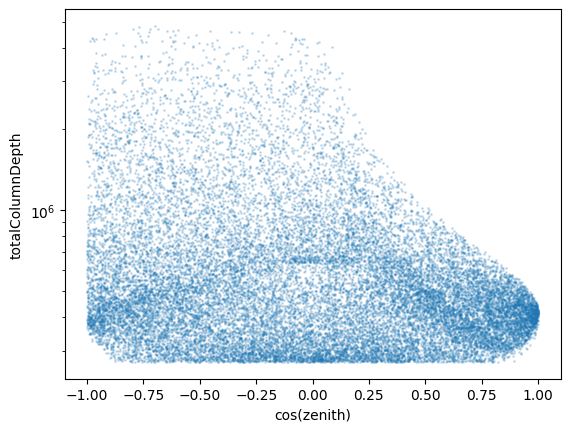

In [9]:
plt.scatter(np.cos(df["zenith"]), df["columnDepth"], s=1, alpha=0.2)
plt.xlabel("cos(zenith)")
plt.ylabel("totalColumnDepth")
plt.yscale("log")
plt.show()

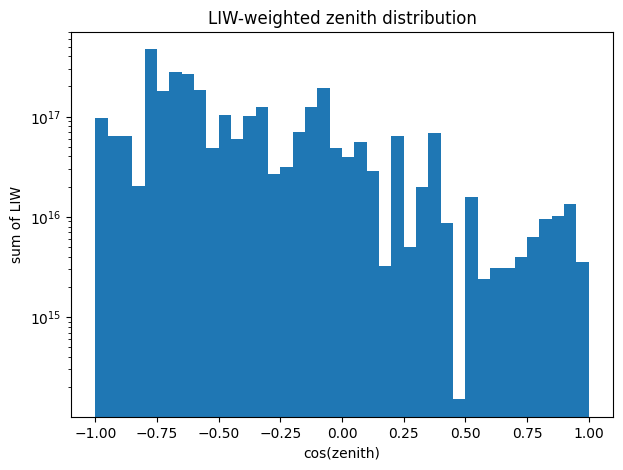

In [10]:
import numpy as np
import matplotlib.pyplot as plt

cosz = np.cos(df["zenith"])
w = df["oneweight"]

valid = (
    np.isfinite(cosz) &
    np.isfinite(w) &
    (w > 0)
)

bins = np.linspace(-1, 1, 41)

plt.figure(figsize=(7,5))
plt.hist(cosz[valid], bins=bins, weights=w[valid])
plt.xlabel("cos(zenith)")
plt.ylabel("sum of LIW")
plt.title("LIW-weighted zenith distribution")
plt.yscale("log")
plt.show()

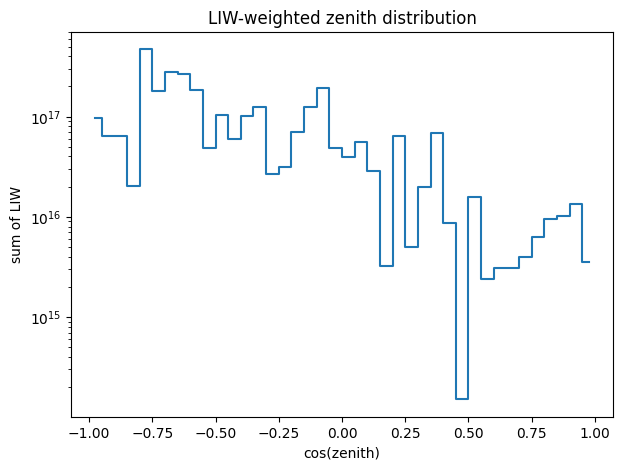

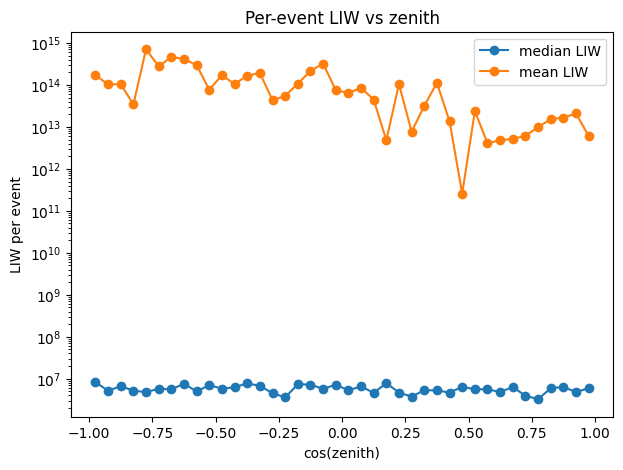

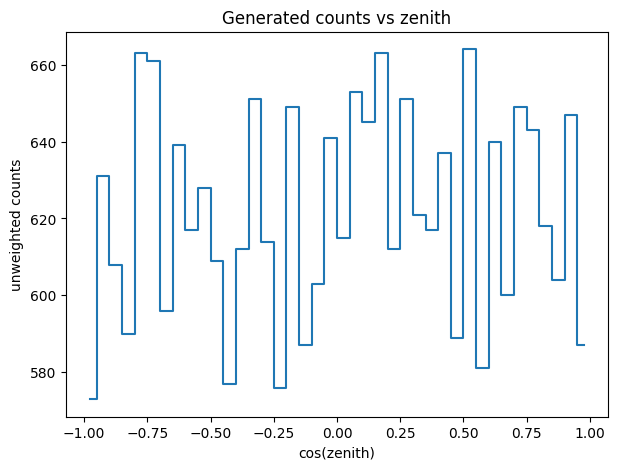

In [11]:
import numpy as np
import matplotlib.pyplot as plt

cosz = np.cos(df["zenith"].values)
w = df["oneweight"].values

valid = (
    np.isfinite(cosz) &
    np.isfinite(w) &
    (w > 0)
)

cosz = cosz[valid]
w = w[valid]

bins = np.linspace(-1, 1, 41)
bin_id = np.digitize(cosz, bins)

x = []
sum_w = []
mean_w = []
median_w = []
counts = []

for i in range(1, len(bins)):
    m = bin_id == i
    if m.sum() == 0:
        continue

    x.append(0.5 * (bins[i - 1] + bins[i]))
    sum_w.append(np.sum(w[m]))
    mean_w.append(np.mean(w[m]))
    median_w.append(np.median(w[m]))
    counts.append(m.sum())

x = np.array(x)
sum_w = np.array(sum_w)
mean_w = np.array(mean_w)
median_w = np.array(median_w)
counts = np.array(counts)

plt.figure(figsize=(7, 5))
plt.step(x, sum_w, where="mid")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("sum of LIW")
plt.title("LIW-weighted zenith distribution")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(x, median_w, marker="o", label="median LIW")
plt.plot(x, mean_w, marker="o", label="mean LIW")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("LIW per event")
plt.title("Per-event LIW vs zenith")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.step(x, counts, where="mid")
plt.xlabel("cos(zenith)")
plt.ylabel("unweighted counts")
plt.title("Generated counts vs zenith")
plt.show()

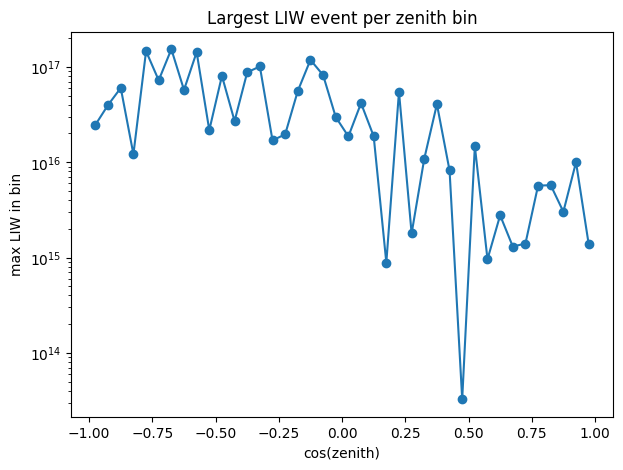

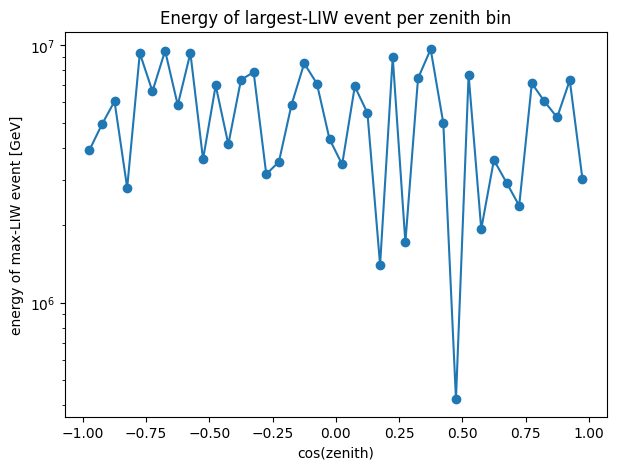

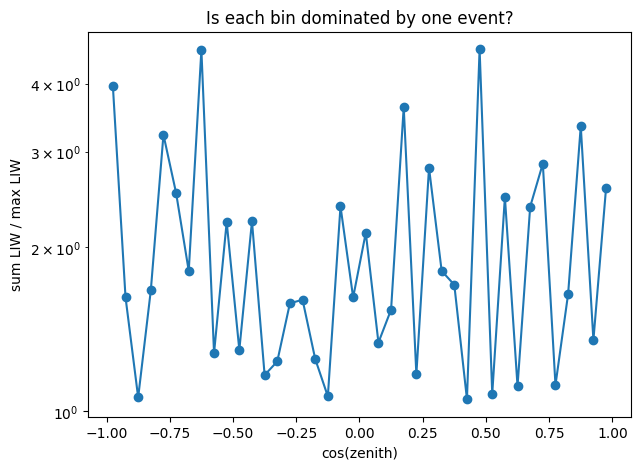

In [12]:
import numpy as np
import matplotlib.pyplot as plt

cosz = np.cos(df["zenith"].values)
E = df["energy"].values
w = df["oneweight"].values

valid = (
    np.isfinite(cosz) &
    np.isfinite(E) &
    np.isfinite(w) &
    (E > 0) &
    (w > 0)
)

cosz = cosz[valid]
E = E[valid]
w = w[valid]

bins = np.linspace(-1, 1, 41)
bin_id = np.digitize(cosz, bins)

x = []
max_w = []
max_E = []
sum_w = []

for i in range(1, len(bins)):
    m = bin_id == i
    if m.sum() == 0:
        continue

    idx = np.argmax(w[m])
    ww = w[m]
    ee = E[m]

    x.append(0.5 * (bins[i - 1] + bins[i]))
    max_w.append(ww[idx])
    max_E.append(ee[idx])
    sum_w.append(np.sum(ww))

x = np.array(x)
max_w = np.array(max_w)
max_E = np.array(max_E)
sum_w = np.array(sum_w)

plt.figure(figsize=(7, 5))
plt.plot(x, max_w, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("max LIW in bin")
plt.title("Largest LIW event per zenith bin")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(x, max_E, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("energy of max-LIW event [GeV]")
plt.title("Energy of largest-LIW event per zenith bin")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(x, sum_w / max_w, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("sum LIW / max LIW")
plt.title("Is each bin dominated by one event?")
plt.show()

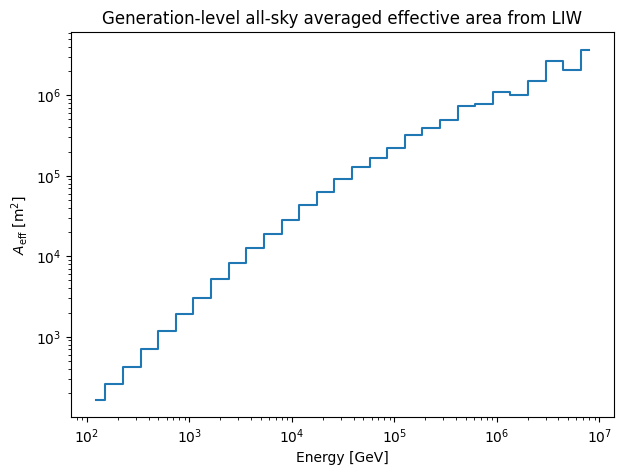

In [4]:
import numpy as np
import matplotlib.pyplot as plt

E = df["energy"].values
w = df["oneweight"].values

valid = (
    np.isfinite(E) &
    np.isfinite(w) &
    (E > 0) &
    (w > 0)
)

E = E[valid]
w = w[valid]

# Energy bins
bins = np.logspace(np.log10(E.min()), np.log10(E.max()), 30)

sum_w, edges = np.histogram(E, bins=bins, weights=w)

centers = np.sqrt(edges[:-1] * edges[1:])
delta_E = np.diff(edges)

# Full sky
delta_omega = 4 * np.pi

# A_eff in cm^2
A_eff_cm2 = sum_w / (delta_E * delta_omega)

# Convert cm^2 to m^2
A_eff_m2 = A_eff_cm2 / 1e4

plt.figure(figsize=(7, 5))
plt.step(centers, A_eff_m2, where="mid")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")

plt.title("Generation-level all-sky averaged effective area from LIW")

plt.show()

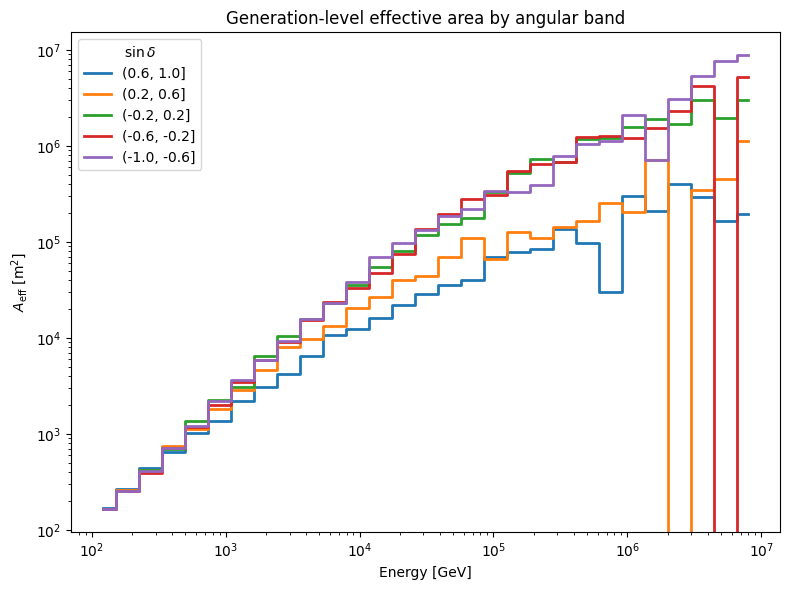

In [5]:
import numpy as np
import matplotlib.pyplot as plt

E = df["energy"].values
w = df["oneweight"].values
sin_delta = np.cos(df["zenith"].values)

valid = (
    np.isfinite(E) &
    np.isfinite(w) &
    np.isfinite(sin_delta) &
    (E > 0) &
    (w > 0)
)

E = E[valid]
w = w[valid]
sin_delta = sin_delta[valid]

# Energy bins
energy_bins = np.logspace(np.log10(E.min()), np.log10(E.max()), 30)
centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
delta_E = np.diff(energy_bins)

# sin(delta) bins
sin_delta_bins = [
    (0.6, 1.0),
    (0.2, 0.6),
    (-0.2, 0.2),
    (-0.6, -0.2),
    (-1.0, -0.6),
]

plt.figure(figsize=(8, 6))

for sd_min, sd_max in sin_delta_bins:
    m = (sin_delta >= sd_min) & (sin_delta < sd_max)

    # Son bin için +1 sınırını dahil et
    if sd_max == 1.0:
        m = (sin_delta >= sd_min) & (sin_delta <= sd_max)

    sum_w, edges = np.histogram(
        E[m],
        bins=energy_bins,
        weights=w[m]
    )

    # Bu angular band için solid angle:
    # dOmega = 2*pi*d(sin_delta)
    delta_omega = 2 * np.pi * (sd_max - sd_min)

    A_eff_cm2 = sum_w / (delta_E * delta_omega)
    A_eff_m2 = A_eff_cm2 / 1e4

    plt.step(
        centers,
        A_eff_m2,
        where="mid",
        linewidth=2,
        label=f"({sd_min:.1f}, {sd_max:.1f}]"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")
plt.title("Generation-level effective area by angular band")
plt.legend(title=r"$\sin\delta$")

plt.tight_layout()
plt.show()

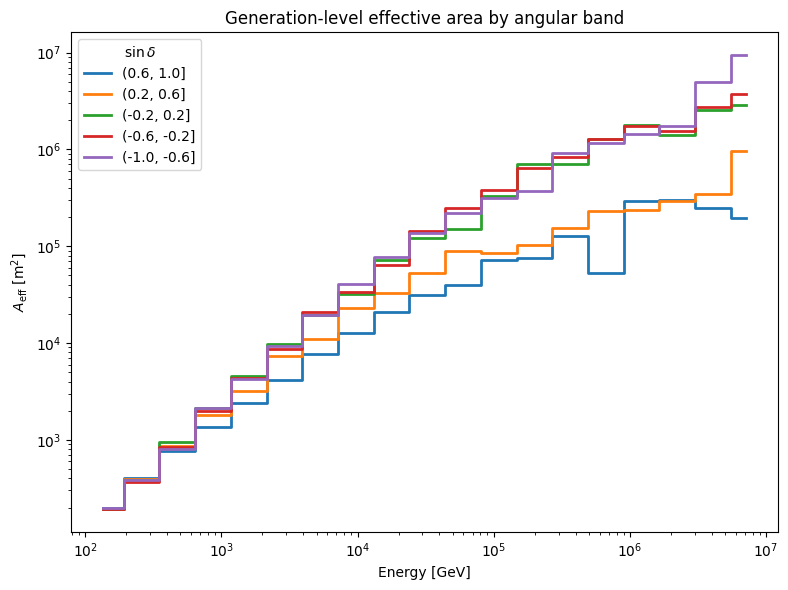

In [6]:
import numpy as np
import matplotlib.pyplot as plt

E = df["energy"].values
w = df["oneweight"].values
sin_delta = np.cos(df["zenith"].values)

valid = (
    np.isfinite(E) &
    np.isfinite(w) &
    np.isfinite(sin_delta) &
    (E > 0) &
    (w > 0)
)

E = E[valid]
w = w[valid]
sin_delta = sin_delta[valid]

# Daha az energy bin kullan: yüksek enerjide daha stabil olur
energy_bins = np.logspace(np.log10(E.min()), np.log10(E.max()), 20)
centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
delta_E = np.diff(energy_bins)

sin_delta_bins = [
    (0.6, 1.0),
    (0.2, 0.6),
    (-0.2, 0.2),
    (-0.6, -0.2),
    (-1.0, -0.6),
]

plt.figure(figsize=(8, 6))

for sd_min, sd_max in sin_delta_bins:
    if sd_max == 1.0:
        m = (sin_delta >= sd_min) & (sin_delta <= sd_max)
    else:
        m = (sin_delta >= sd_min) & (sin_delta < sd_max)

    sum_w, edges = np.histogram(
        E[m],
        bins=energy_bins,
        weights=w[m]
    )

    counts, _ = np.histogram(
        E[m],
        bins=energy_bins
    )

    delta_omega = 2 * np.pi * (sd_max - sd_min)

    A_eff_cm2 = sum_w / (delta_E * delta_omega)
    A_eff_m2 = A_eff_cm2 / 1e4

    # Sadece dolu binleri çiz
    nonzero = (sum_w > 0) & (counts > 0)

    plt.step(
        centers[nonzero],
        A_eff_m2[nonzero],
        where="mid",
        linewidth=2,
        label=f"({sd_min:.1f}, {sd_max:.1f}]"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")
plt.title("Generation-level effective area by angular band")
plt.legend(title=r"$\sin\delta$")

plt.tight_layout()
plt.show()